In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import folium
from folium.plugins import MarkerCluster, HeatMap

from pyspark.sql import functions as F

os.makedirs("figures", exist_ok=True)
os.makedirs("figures/maps", exist_ok=True)

/usr/lib/python3/dist-packages/mpl_toolkits/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)
/home/vagrant/.local/lib/python3.9/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/vagrant/.local/lib/python3.9/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (1.26.6) or chardet (2.3.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
try:
    spark
    print("SparkSession already exists")
except NameError:
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.appName("BigData-Visualizations").getOrCreate()
    print("SparkSession created")

SparkSession already exists


In [3]:
HDFS_BASE = "hdfs:///user/vagrant"

HDFS_LISTINGS_WITH_POLICE = f"{HDFS_BASE}/bigdata/analytical/listings_with_police_stats"
HDFS_NEIGHBOURHOOD_STATS  = f"{HDFS_BASE}/bigdata/analytical/neighbourhood_stats"
HDFS_CITY_COMPARISONS     = f"{HDFS_BASE}/bigdata/analytical/city_comparisons"
HDFS_POLICE_GEOHASH_AGG   = f"{HDFS_BASE}/bigdata/analytical/police_geohash_agg"

(HDFS_LISTINGS_WITH_POLICE, HDFS_NEIGHBOURHOOD_STATS, HDFS_CITY_COMPARISONS, HDFS_POLICE_GEOHASH_AGG)

('hdfs:///user/vagrant/bigdata/analytical/listings_with_police_stats',
 'hdfs:///user/vagrant/bigdata/analytical/neighbourhood_stats',
 'hdfs:///user/vagrant/bigdata/analytical/city_comparisons',
 'hdfs:///user/vagrant/bigdata/analytical/police_geohash_agg')

In [4]:
listings_df   = spark.read.parquet(HDFS_LISTINGS_WITH_POLICE)
neigh_df      = spark.read.parquet(HDFS_NEIGHBOURHOOD_STATS)
city_df       = spark.read.parquet(HDFS_CITY_COMPARISONS)
police_geo_df = spark.read.parquet(HDFS_POLICE_GEOHASH_AGG)

print("listings_df columns:", listings_df.columns)
print("neigh_df columns   :", neigh_df.columns)
print("city_df columns    :", city_df.columns)
print("police_geo_df cols :", police_geo_df.columns)

listings_df columns: ['id', 'city_code', 'neighbourhood_cleansed', 'latitude_d', 'longitude_d', 'geohash5', 'price_num', 'room_type', 'property_type', 'accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'availability_365', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate', 'crime_events_total', 'crime_events_distinct', 'crime_types_distinct', 'top_crime_desc', 'top_crime_desc_count', 'safety_index', 'crime_bucket']
neigh_df columns   : ['city_code', 'neighbourhood_cleansed', 'listing_count', 'avg_price', 'median_price', 'avg_rating', 'median_rating', 'avg_crimes_nearby', 'median_crimes_nearby', 'avg_safety_index', 'median_safety_index', 'bucket_0_cnt', 'bucket_1_5_cnt', 'bucket_6_20_cnt', 'bucket_21p_cnt', 'crimes_per_100_listings']
city_df columns    : ['city_code', 'listing_count', 'avg_price', 'median_price', 'avg_rating', 'median_rating', 'avg_crimes_nearby', 'median_crimes_nearby', 'avg_safety_index', 'median_safety_index', 'bucket_0_cn

In [5]:
listings_df.groupBy("city_code").count().show()
neigh_df.groupBy("city_code").count().show()
police_geo_df.groupBy("city_code").count().show()

# City comparisons to mała tabela (2 wiersze)
city_df.show(20, truncate=False)

+---------+-----+
|city_code|count|
+---------+-----+
|      LON|  200|
|      NYC|  200|
+---------+-----+



+---------+-----+
|city_code|count|
+---------+-----+
|      LON|   27|
|      NYC|   52|
+---------+-----+



+---------+-----+
|city_code|count|
+---------+-----+
|      LON|  435|
|      NYC|   51|
+---------+-----+

+---------+-------------+------------------+------------+-----------------+-------------+-----------------+--------------------+--------------------+--------------------+------------+--------------+---------------+--------------+------------+--------------+---------------+--------------+--------------------+--------------------+--------------------+
|city_code|listing_count|avg_price         |median_price|avg_rating       |median_rating|avg_crimes_nearby|median_crimes_nearby|avg_safety_index    |median_safety_index |bucket_0_cnt|bucket_1_5_cnt|bucket_6_20_cnt|bucket_21p_cnt|bucket_0_pct|bucket_1_5_pct|bucket_6_20_pct|bucket_21p_pct|corr_price_vs_crime |corr_rating_vs_crime|corr_price_vs_safety|
+---------+-------------+------------------+------------+-----------------+-------------+-----------------+--------------------+--------------------+--------------------+------------+----

In [6]:
LISTINGS_LIMIT = 5000

listings_cols = [
    "id","city_code","neighbourhood_cleansed","latitude_d","longitude_d","geohash5",
    "price_num","review_scores_rating","number_of_reviews",
    "crime_events_total","crime_events_distinct","crime_types_distinct",
    "top_crime_desc","top_crime_desc_count","safety_index","crime_bucket"
]
listings_cols = [c for c in listings_cols if c in listings_df.columns]

listings_pdf = listings_df.select(*listings_cols).limit(LISTINGS_LIMIT).toPandas()
neigh_pdf = neigh_df.toPandas()
city_pdf = city_df.toPandas()
police_geo_pdf = police_geo_df.toPandas()

print("listings_pdf:", listings_pdf.shape)
print("neigh_pdf:", neigh_pdf.shape)
print("city_pdf:", city_pdf.shape)
print("police_geo_pdf:", police_geo_pdf.shape)

listings_pdf.head()


[Stage 40:======================================>                   (4 + 2) / 6]

listings_pdf: (400, 16)
neigh_pdf: (79, 16)
city_pdf: (2, 21)
police_geo_pdf: (486, 7)


,id,city_code,neighbourhood_cleansed,latitude_d,longitude_d,geohash5,price_num,review_scores_rating,number_of_reviews,crime_events_total,crime_events_distinct,crime_types_distinct,top_crime_desc,top_crime_desc_count,safety_index,crime_bucket
0,40864895,NYC,Bath Beach,40.604950,-74.012619,dr5qg,NaN,5.00,1,1,1,1,GRAND LARCENY,1,0.500000,1-5
1,100186,NYC,Gowanus,40.669521,-73.992012,dr5rk,150.0,4.94,125,8,8,6,GRAND LARCENY,2,0.111111,6-20
2,46911,NYC,Park Slope,40.680099,-73.974617,dr5rk,86.0,4.73,77,8,8,6,GRAND LARCENY,2,0.111111,6-20
3,40838018,NYC,Clinton Hill,40.683701,-73.961151,dr5rk,NaN,5.00,1,8,8,6,GRAND LARCENY,2,0.111111,6-20
4,42729,NYC,Carroll Gardens,40.678131,-74.000618,dr5rk,254.0,4.67,219,8,8,6,GRAND LARCENY,2,0.111111,6-20


In [7]:
num_cols = [
    "price_num", "review_scores_rating", "number_of_reviews",
    "crime_events_total", "crime_events_distinct", "crime_types_distinct",
    "top_crime_desc_count", "safety_index"
]
for c in num_cols:
    if c in listings_pdf.columns:
        listings_pdf[c] = pd.to_numeric(listings_pdf[c], errors="coerce")

for c in ["avg_price","median_price","avg_rating","median_rating","avg_crimes_nearby","median_crimes_nearby","crimes_per_100_listings"]:
    if c in neigh_pdf.columns:
        neigh_pdf[c] = pd.to_numeric(neigh_pdf[c], errors="coerce")

for c in ["avg_price","median_price","avg_rating","median_rating","avg_crimes_nearby","median_crimes_nearby",
          "avg_safety_index","median_safety_index","corr_price_vs_crime","corr_rating_vs_crime","corr_price_vs_safety"]:
    if c in city_pdf.columns:
        city_pdf[c] = pd.to_numeric(city_pdf[c], errors="coerce")


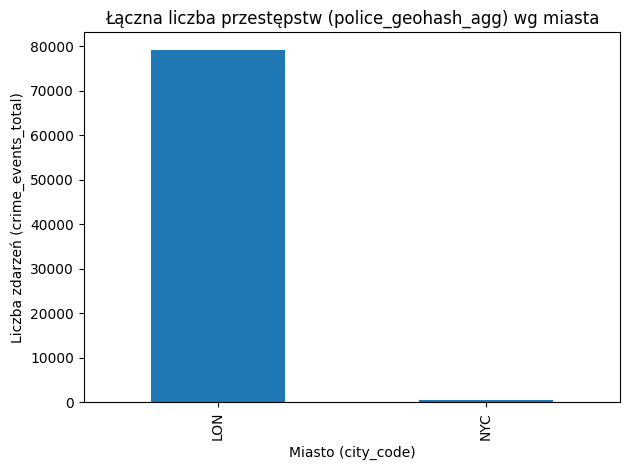

In [8]:
# Wykres 1: Łączna liczba przestępstw wg miasta

city_crimes = (police_geo_pdf.groupby("city_code")["crime_events_total"]
               .sum()
               .sort_values(ascending=False))

plt.figure()
city_crimes.plot(kind="bar")
plt.title("Łączna liczba przestępstw (police_geohash_agg) wg miasta")
plt.ylabel("Liczba zdarzeń (crime_events_total)")
plt.xlabel("Miasto (city_code)")
plt.tight_layout()
plt.savefig("figures/01_crimes_by_city.png", dpi=200)
plt.show()

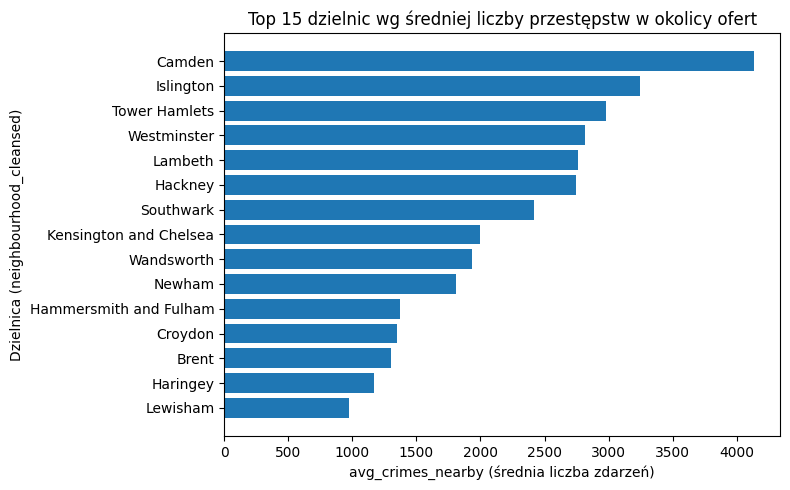

In [9]:
# Wykres 2: Top 15 obszarów wg przestępczości

topN = 15
tmp = neigh_pdf[["city_code","neighbourhood_cleansed","avg_crimes_nearby"]].dropna()
tmp = tmp.sort_values("avg_crimes_nearby", ascending=False).head(topN).iloc[::-1]

plt.figure(figsize=(8,5))
plt.barh(tmp["neighbourhood_cleansed"].astype(str), tmp["avg_crimes_nearby"])
plt.title(f"Top {topN} dzielnic wg średniej liczby przestępstw w okolicy ofert")
plt.xlabel("avg_crimes_nearby (średnia liczba zdarzeń)")
plt.ylabel("Dzielnica (neighbourhood_cleansed)")
plt.tight_layout()
plt.savefig("figures/02_top_neighbourhoods_by_avg_crimes.png", dpi=200)
plt.show()

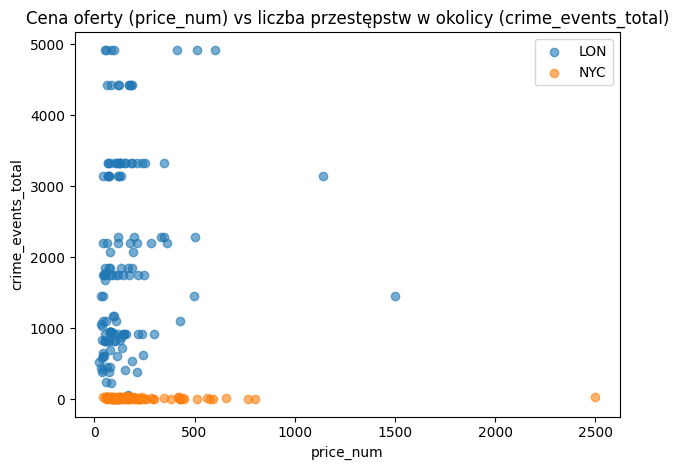

In [10]:
# Wykres 3: Cena vs przestępstwa w okolicy

tmp = listings_pdf[["city_code","price_num","crime_events_total"]].dropna()

plt.figure()
for city, g in tmp.groupby("city_code"):
    plt.scatter(g["price_num"], g["crime_events_total"], label=str(city), alpha=0.6)

plt.title("Cena oferty (price_num) vs liczba przestępstw w okolicy (crime_events_total)")
plt.xlabel("price_num")
plt.ylabel("crime_events_total")
plt.legend()
plt.tight_layout()
plt.savefig("figures/03_price_vs_crime_scatter.png", dpi=200)
plt.show()


/tmp/ipykernel_23891/624578962.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cities, showfliers=False)


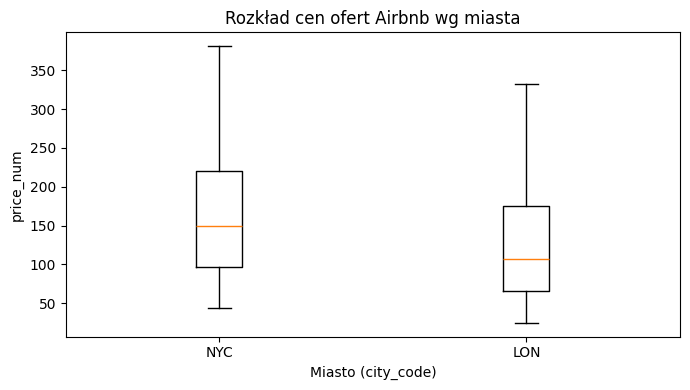

In [11]:
# Wykres 4: Boxplot cen wg miasta

tmp = listings_pdf[["city_code","price_num"]].dropna()
cities = list(tmp["city_code"].unique())
data = [tmp.loc[tmp["city_code"] == c, "price_num"].values for c in cities]

plt.figure(figsize=(7,4))
plt.boxplot(data, labels=cities, showfliers=False)
plt.title("Rozkład cen ofert Airbnb wg miasta")
plt.xlabel("Miasto (city_code)")
plt.ylabel("price_num")
plt.tight_layout()
plt.savefig("figures/04_price_boxplot_by_city.png", dpi=200)
plt.show()

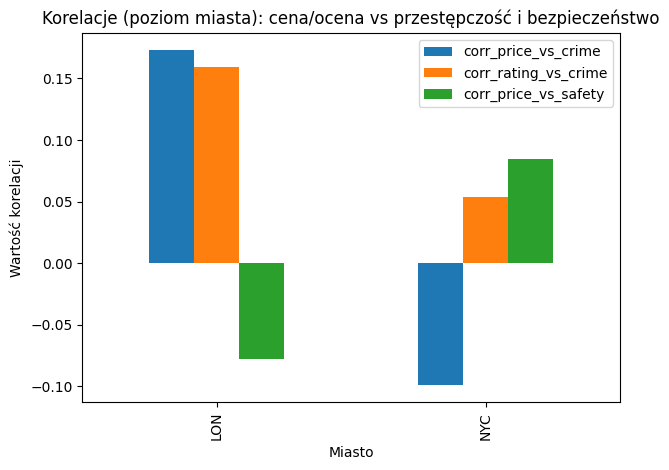

In [12]:
# Wykres 5: Korelacja price vs crime (na poziomie miast) + inne korelacje

cols = ["city_code","corr_price_vs_crime","corr_rating_vs_crime","corr_price_vs_safety"]
tmp = city_pdf[cols].copy().set_index("city_code")

tmp.plot(kind="bar")
plt.title("Korelacje (poziom miasta): cena/ocena vs przestępczość i bezpieczeństwo")
plt.ylabel("Wartość korelacji")
plt.xlabel("Miasto")
plt.tight_layout()
plt.savefig("figures/05_city_level_correlations.png", dpi=200)
plt.show()

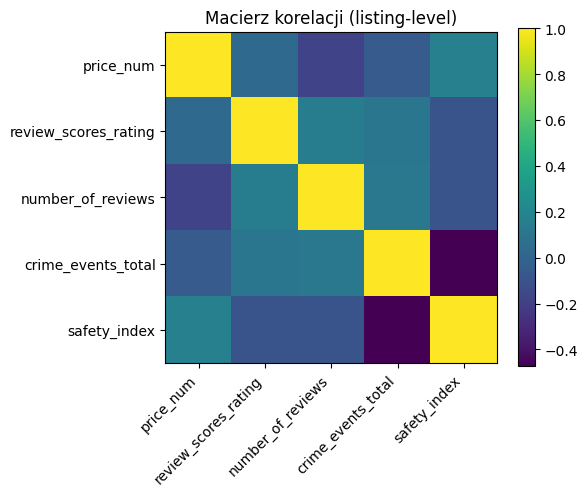

In [13]:
# Wykres 6: Macierz korelacji (listing-level) dla kluczowych zmiennych

corr_cols = ["price_num","review_scores_rating","number_of_reviews","crime_events_total","safety_index"]
tmp = listings_pdf[corr_cols].copy()

for c in corr_cols:
    tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

tmp = tmp.dropna()
corr = tmp.corr(numeric_only=True)

plt.figure(figsize=(6,5))
plt.imshow(corr.values)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Macierz korelacji (listing-level)")
plt.colorbar()
plt.tight_layout()
plt.savefig("figures/06_listing_level_correlation_heatmap.png", dpi=200)
plt.show()

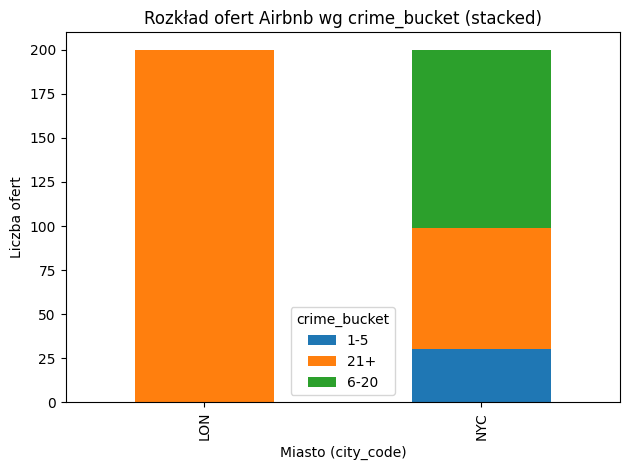

In [14]:
# Wykres 7: Udział ofert w bucketach przestępczości (stacked bar)
# rozkład ofert w kategoriach crime_bucket (np. 0, 1-5, 6-20, 21+)

bucket_counts = listings_pdf.groupby(["city_code","crime_bucket"]).size().unstack(fill_value=0)

bucket_counts.plot(kind="bar", stacked=True)
plt.title("Rozkład ofert Airbnb wg crime_bucket (stacked)")
plt.xlabel("Miasto (city_code)")
plt.ylabel("Liczba ofert")
plt.tight_layout()
plt.savefig("figures/07_crime_bucket_distribution.png", dpi=200)
plt.show()

In [15]:
# Mapy 1: Oferty Airbnb (MarkerCluster) dla NYC i LON

tmp = listings_pdf[["latitude_d","longitude_d","city_code","price_num","crime_events_total"]].dropna()

MAP_LIMIT = 2000  # żeby mapa była płynna

for CITY_FOR_MAP in ["NYC", "LON"]:
    tmp_city = tmp[tmp["city_code"] == CITY_FOR_MAP].copy()
    if tmp_city.shape[0] == 0:
        print(f"Brak danych listings dla {CITY_FOR_MAP} – pomijam mapę.")
        continue

    if tmp_city.shape[0] > MAP_LIMIT:
        tmp_city = tmp_city.sample(MAP_LIMIT, random_state=42)

    center = [tmp_city["latitude_d"].mean(), tmp_city["longitude_d"].mean()]
    m = folium.Map(location=center, zoom_start=11)
    cluster = MarkerCluster().add_to(m)

    for _, r in tmp_city.iterrows():
        popup = f"city: {CITY_FOR_MAP}<br>price_num: {r['price_num']}<br>crime_events_total: {r['crime_events_total']}"
        folium.Marker(
            location=[r["latitude_d"], r["longitude_d"]],
            popup=popup
        ).add_to(cluster)

    out_path = f"figures/maps/01_listings_map_{CITY_FOR_MAP}.html"
    m.save(out_path)
    print("Saved:", out_path)


Saved: figures/maps/01_listings_map_NYC.html
Saved: figures/maps/01_listings_map_LON.html


In [16]:
# Mapy 2: Heatmap "crime near listings" dla NYC i LON

tmp = listings_pdf[["latitude_d","longitude_d","city_code","crime_events_total"]].dropna()

HEAT_LIMIT = 2000  # ograniczenie punktów

for CITY_FOR_MAP in ["NYC", "LON"]:
    tmp_city = tmp[tmp["city_code"] == CITY_FOR_MAP].copy()
    if tmp_city.shape[0] == 0:
        print(f"Brak danych do heatmapy dla {CITY_FOR_MAP} – pomijam.")
        continue

    if tmp_city.shape[0] > HEAT_LIMIT:
        tmp_city = tmp_city.sample(HEAT_LIMIT, random_state=42)

    center = [tmp_city["latitude_d"].mean(), tmp_city["longitude_d"].mean()]
    m = folium.Map(location=center, zoom_start=11)

    heat_data = [[r["latitude_d"], r["longitude_d"], float(r["crime_events_total"])] for _, r in tmp_city.iterrows()]
    HeatMap(heat_data, radius=12).add_to(m)

    out_path = f"figures/maps/02_crime_heatmap_{CITY_FOR_MAP}.html"
    m.save(out_path)
    print("Saved:", out_path)


Saved: figures/maps/02_crime_heatmap_NYC.html
Saved: figures/maps/02_crime_heatmap_LON.html


In [17]:
# MAP OVERLAY: Airbnb listings + Crime heatmap (NYC i LON)
# jednocześnie rozmieszczenie ofert Airbnb (punkty) oraz intensywność przestępczości w ich pobliżu (heatmapa)

from folium.plugins import MarkerCluster, HeatMap

tmp = listings_pdf[
    ["latitude_d", "longitude_d", "city_code", "price_num", "crime_events_total"]
].dropna()

MAP_LIMIT = 1500  # bezpieczeństwo wydajności

for CITY_FOR_MAP in ["NYC", "LON"]:
    df_city = tmp[tmp["city_code"] == CITY_FOR_MAP].copy()
    if df_city.empty:
        print(f"Brak danych dla {CITY_FOR_MAP}, pomijam.")
        continue

    if len(df_city) > MAP_LIMIT:
        df_city = df_city.sample(MAP_LIMIT, random_state=42)

    center = [df_city["latitude_d"].mean(), df_city["longitude_d"].mean()]
    m = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")

    # ===== WARSTWA 1: Airbnb listings (punkty) =====
    listings_layer = folium.FeatureGroup(name="Airbnb listings")
    cluster = MarkerCluster().add_to(listings_layer)

    for _, r in df_city.iterrows():
        popup = (
            f"<b>City:</b> {CITY_FOR_MAP}<br>"
            f"<b>Price:</b> {r.get('price_num', 'NA')}<br>"
            f"<b>Crime events nearby:</b> {r.get('crime_events_total', 'NA')}"
        )
        folium.CircleMarker(
            location=[r["latitude_d"], r["longitude_d"]],
            radius=4,
            color="blue",
            fill=True,
            fill_opacity=0.7,
            popup=popup
        ).add_to(cluster)

    listings_layer.add_to(m)

    # ===== WARSTWA 2: Crime heatmap =====
    heat_layer = folium.FeatureGroup(name="Crime intensity (heatmap)")

    heat_data = [
        [r["latitude_d"], r["longitude_d"], float(r["crime_events_total"])]
        for _, r in df_city.iterrows()
        if r["crime_events_total"] > 0
    ]

    HeatMap(
        heat_data,
        radius=15,
        blur=12,
        min_opacity=0.3
    ).add_to(heat_layer)

    heat_layer.add_to(m)

    # ===== Kontrola warstw =====
    folium.LayerControl(collapsed=False).add_to(m)

    out_path = f"figures/maps/03_overlay_airbnb_crime_{CITY_FOR_MAP}.html"
    m.save(out_path)
    print("Saved:", out_path)


Saved: figures/maps/03_overlay_airbnb_crime_NYC.html
Saved: figures/maps/03_overlay_airbnb_crime_LON.html


In [18]:
# BUBBLE MAP — Airbnb punkty, radius zależny od crime_events_total, popup z detalami
# Co pokazuje: gdzie są oferty + jak silna jest przestępczość w okolicy

CITY = "LON"  # albo "LON"

df_city = listings_pdf[
    (listings_pdf["city_code"] == CITY)
][["latitude_d","longitude_d","price_num","crime_events_total","crime_bucket"]].dropna()

# limit żeby mapa była płynna
if len(df_city) > 2000:
    df_city = df_city.sample(2000, random_state=42)

center = [df_city["latitude_d"].mean(), df_city["longitude_d"].mean()]
m = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")

# prosta funkcja: radius rośnie logarytmicznie, żeby nie było gigantycznych kółek
def radius_from_crime(x):
    return 3 + np.log1p(x)  # log(1+x)

for _, r in df_city.iterrows():
    rad = float(radius_from_crime(r["crime_events_total"]))
    popup = (f"price: {r['price_num']}<br>"
             f"crime_events_total: {r['crime_events_total']}<br>"
             f"crime_bucket: {r['crime_bucket']}")
    folium.CircleMarker(
        location=[r["latitude_d"], r["longitude_d"]],
        radius=rad,
        fill=True,
        fill_opacity=0.5,
        popup=popup
    ).add_to(m)

out_path = f"figures/maps/04_bubble_map_{CITY}.html"
m.save(out_path)
out_path


'figures/maps/04_bubble_map_LON.html'

In [19]:
# TOP LISTINGS MAP — pokazuje skrajne przypadki: najbardziej i najmniej "bezpieczne" oferty
# Co pokazuje: gdzie są skrajnie niebezpieczne i skrajnie bezpieczne listingi

CITY = "NYC"  # albo "LON"

df_city = listings_pdf[listings_pdf["city_code"] == CITY].copy()
df_city = df_city[["latitude_d","longitude_d","price_num","crime_events_total","safety_index"]].dropna()

# Top N
N = 20
most_danger = df_city.sort_values("crime_events_total", ascending=False).head(N)
most_safe   = df_city.sort_values("crime_events_total", ascending=True).head(N)

center = [df_city["latitude_d"].mean(), df_city["longitude_d"].mean()]
m = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")

danger_layer = folium.FeatureGroup(name=f"Top {N} most dangerous (crime_events_total)")
safe_layer   = folium.FeatureGroup(name=f"Top {N} safest (crime_events_total)")

for _, r in most_danger.iterrows():
    popup = f"DANGER<br>crime: {r['crime_events_total']}<br>price: {r['price_num']}<br>safety: {r['safety_index']}"
    folium.CircleMarker(
        location=[r["latitude_d"], r["longitude_d"]],
        radius=7,
        color="red",
        fill=True,
        fill_opacity=0.7,
        popup=popup
    ).add_to(danger_layer)

for _, r in most_safe.iterrows():
    popup = f"SAFE<br>crime: {r['crime_events_total']}<br>price: {r['price_num']}<br>safety: {r['safety_index']}"
    folium.CircleMarker(
        location=[r["latitude_d"], r["longitude_d"]],
        radius=7,
        color="green",
        fill=True,
        fill_opacity=0.7,
        popup=popup
    ).add_to(safe_layer)

danger_layer.add_to(m)
safe_layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

out_path = f"figures/maps/05_top_safe_vs_danger_{CITY}.html"
m.save(out_path)
out_path

'figures/maps/05_top_safe_vs_danger_NYC.html'

In [20]:
# Sprawdzenie struktury geojson

import json

with open("/home/vagrant/neighbourhoods_nyc.geojson", "r", encoding="utf-8") as f:
    gj_nyc = json.load(f)

print("NYC properties keys:")
print(gj_nyc["features"][0]["properties"].keys())

NYC properties keys:
dict_keys(['neighbourhood', 'neighbourhood_group'])


In [21]:
# CHOROPLETH NYC
# dzielnice NYC pokolorowane wg avg_crimes_nearby - wizualna koncentracja przestępczości w skali miasta

import json
import folium

CITY = "NYC"
GEOJSON_PATH = "/home/vagrant/neighbourhoods_nyc.geojson"
GEO_KEY = "neighbourhood"   # <-- zmień, jeśli w CELL A wyszło inaczej

# 1) Dane statystyczne
stats = (
    neigh_pdf[neigh_pdf["city_code"] == CITY]
    [["neighbourhood_cleansed", "avg_crimes_nearby"]]
    .dropna()
)

# 2) GeoJSON
with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
    gj = json.load(f)

# 3) Centrum mapy
tmp = listings_pdf[listings_pdf["city_code"] == CITY][["latitude_d","longitude_d"]].dropna()
center = [tmp["latitude_d"].mean(), tmp["longitude_d"].mean()]

m = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")

# 4) Choropleth
folium.Choropleth(
    geo_data=gj,
    data=stats,
    columns=["neighbourhood_cleansed", "avg_crimes_nearby"],
    key_on=f"feature.properties.{GEO_KEY}",
    fill_opacity=0.75,
    line_opacity=0.3,
    legend_name="Średnia liczba przestępstw w pobliżu ofert Airbnb"
).add_to(m)

folium.LayerControl().add_to(m)

out_path = "figures/maps/06_choropleth_NYC.html"
m.save(out_path)
out_path


'figures/maps/06_choropleth_NYC.html'

In [22]:
# CHOROPLETH LONDON
# dzielnice Londynu pokolorowane wg avg_crimes_nearby - wizualna koncentracja przestępczości w skali miasta

CITY = "LON"
GEOJSON_PATH = "/home/vagrant/neighbourhoods_lon.geojson"
GEO_KEY = "neighbourhood"   # <-- zmień tylko jeśli trzeba

stats = (
    neigh_pdf[neigh_pdf["city_code"] == CITY]
    [["neighbourhood_cleansed", "avg_crimes_nearby"]]
    .dropna()
)

with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
    gj = json.load(f)

tmp = listings_pdf[listings_pdf["city_code"] == CITY][["latitude_d","longitude_d"]].dropna()
center = [tmp["latitude_d"].mean(), tmp["longitude_d"].mean()]

m = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=gj,
    data=stats,
    columns=["neighbourhood_cleansed", "avg_crimes_nearby"],
    key_on=f"feature.properties.{GEO_KEY}",
    fill_opacity=0.75,
    line_opacity=0.3,
    legend_name="Średnia liczba przestępstw w pobliżu ofert Airbnb"
).add_to(m)

folium.LayerControl().add_to(m)

out_path = "figures/maps/06_choropleth_LON.html"
m.save(out_path)
out_path


'figures/maps/06_choropleth_LON.html'